<a href="https://www.kaggle.com/code/oladayofolasire/multiple-linear-regression-on-mental-health-data?scriptVersionId=309266359" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Import packages for data manipulation
# Import relevant libraries and modules.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This displays all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# This module lets us save our models once we fit them.
import pickle

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/oladayofolasire/mental-health-in-tech/survey.csv


In [2]:
# Read in data
file = '/kaggle/input/datasets/oladayofolasire/mental-health-in-tech/survey.csv'
data = pd.read_csv(file)
data.head(10)

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
5,2014-08-27 11:31:22,33,Male,United States,TN,NaN,Yes,No,Sometimes,6-25,No,Yes,Yes,Not sure,No,Don't know,Don't know,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No,NaN
6,2014-08-27 11:31:50,35,Female,United States,MI,NaN,Yes,Yes,Sometimes,1-5,Yes,Yes,No,No,No,No,No,Somewhat difficult,Maybe,Maybe,Some of them,No,No,No,Don't know,No,NaN
7,2014-08-27 11:32:05,39,M,Canada,NaN,NaN,No,No,Never,1-5,Yes,Yes,No,Yes,No,No,Yes,Don't know,No,No,No,No,No,No,No,No,NaN
8,2014-08-27 11:32:39,42,Female,United States,IL,NaN,Yes,Yes,Sometimes,100-500,No,Yes,Yes,Yes,No,No,No,Very difficult,Maybe,No,Yes,Yes,No,Maybe,No,No,NaN
9,2014-08-27 11:32:43,23,Male,Canada,NaN,NaN,No,No,Never,26-100,No,Yes,Don't know,No,Don't know,Don't know,Don't know,Don't know,No,No,Yes,Yes,Maybe,Maybe,Yes,No,NaN


In [3]:
##Null Hypothesis (H₀): None of the selected X variables have a significant relationship with Age of tech workers.##

In [4]:
##Alternative Hypothesis (H₁): At least one of the selected X variables has a significant relationship with Age.##

In [5]:
data.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [7]:
data.dtypes

Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments                     object
dtype: object

In [8]:
data.shape

(1259, 27)

In [9]:
data.size

33993

In [10]:
df_clean = data

In [11]:
# Columns to drop
cols_to_drop = [
    'Timestamp',       # identifier, not meaningful for age
    'state',           # too granular, optional
    'comments',        # free text
    'obs_consequence'  # free text / unclear meaning
]

# Drop them from the dataframe
df_clean = df_clean.drop(columns=cols_to_drop)

# Check the remaining columns
df_clean.head()

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical
0,37,Female,United States,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes
1,44,M,United States,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know
2,32,Male,Canada,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No
3,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No
4,31,Male,United States,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know


In [12]:
# Check for missing values
df_clean.isna().sum()

Age                            0
Gender                         0
Country                        0
self_employed                 18
family_history                 0
treatment                      0
work_interfere               264
no_employees                   0
remote_work                    0
tech_company                   0
benefits                       0
care_options                   0
wellness_program               0
seek_help                      0
anonymity                      0
leave                          0
mental_health_consequence      0
phys_health_consequence        0
coworkers                      0
supervisor                     0
mental_health_interview        0
phys_health_interview          0
mental_vs_physical             0
dtype: int64

In [13]:
# drop NAN##
df_clean.dropna(inplace=True)

In [14]:
df_clean.head(10)

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical
18,46,male,United States,Yes,Yes,No,Sometimes,1-5,Yes,Yes,Yes,Not sure,Yes,Don't know,Yes,Very easy,No,No,Yes,Yes,No,Yes,Yes
20,29,Male,United States,No,Yes,Yes,Sometimes,100-500,No,Yes,Yes,Yes,No,No,No,Somewhat difficult,Maybe,No,Some of them,Some of them,No,No,No
21,31,male,United States,Yes,No,No,Never,1-5,Yes,Yes,No,No,No,No,Yes,Somewhat difficult,No,No,Some of them,Some of them,No,Maybe,Yes
22,46,Male,United States,No,No,Yes,Often,26-100,Yes,Yes,Yes,Yes,No,No,Don't know,Don't know,Maybe,No,Some of them,Yes,No,Maybe,No
23,41,Male,United States,No,No,Yes,Never,More than 1000,No,No,Don't know,No,No,Don't know,Don't know,Don't know,Maybe,No,No,No,No,Yes,Don't know
24,33,male,United States,No,Yes,Yes,Rarely,26-100,No,Yes,Yes,Not sure,Don't know,Yes,Yes,Don't know,No,No,Yes,Yes,No,Yes,Don't know
25,35,male,United States,No,Yes,Yes,Sometimes,More than 1000,No,No,Yes,Yes,No,Don't know,No,Very easy,Yes,No,Some of them,Yes,No,Yes,No
27,35,Female,United States,No,Yes,Yes,Rarely,6-25,Yes,Yes,Yes,Yes,Don't know,Don't know,Don't know,Don't know,No,No,Yes,Yes,Maybe,Maybe,Yes
28,34,male,United States,No,No,Yes,Sometimes,26-100,Yes,Yes,Don't know,Not sure,No,Don't know,Don't know,Somewhat difficult,No,No,Some of them,No,No,No,No
29,37,Male,United Kingdom,No,No,No,Sometimes,6-25,No,Yes,No,No,No,No,Don't know,Very difficult,Yes,Maybe,Some of them,No,No,Maybe,No


In [15]:
df_clean.describe()

,Age
count,9.770000e+02
mean,1.023542e+08
std,3.199283e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [16]:
df_clean.dtypes

Age                           int64
Gender                       object
Country                      object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
dtype: object

In [17]:
# For one column, e.g., 'Gender'
df_clean['Gender'].value_counts()

# For all object/categorical columns
for col in df_clean.select_dtypes(include='object').columns:
    print(f"Column: {col}")
    print(df_clean[col].value_counts())
    print("--------------------")

Column: Gender
Gender
Male                                              471
male                                              156
Female                                            103
M                                                  85
female                                             51
F                                                  31
m                                                  23
f                                                  13
Make                                                4
Male                                                3
Cis Male                                            2
Female (trans)                                      2
Female                                              2
Cis Female                                          1
Male-ish                                            1
Trans-female                                        1
woman                                               1
Nah                                                 1
non-bi

In [18]:
# Standardize Gender values
df_clean['Gender'] = df_clean['Gender'].str.lower().str.strip()  # lowercase & strip spaces
df_clean['Gender'] = df_clean['Gender'].replace({
    'm': 'male', 'male-ish': 'male', 'msle': 'male', 'mal': 'male', 'mail': 'male',
    'f': 'female', 'woman': 'female', 'cis female': 'female', 'female (cis)': 'female',
    'make': 'male', 'cismale': 'male', 'cis male': 'male', 'female (trans)': 'female'
})

# Check unique values after cleaning
df_clean['Gender'].value_counts()

Gender
male                                              749
female                                            206
trans-female                                        1
queer/she/they                                      1
non-binary                                          1
nah                                                 1
all                                                 1
enby                                                1
fluid                                               1
genderqueer                                         1
androgyne                                           1
agender                                             1
cis-female/femme                                    1
guy (-ish) ^_^                                      1
male leaning androgynous                            1
trans woman                                         1
neuter                                              1
queer                                               1
a little about you   

In [19]:
# Columns to convert
binary_cols = ['self_employed', 'treatment', 'remote_work', 'tech_company']

# Map Yes/No to 1/0
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Check
df_clean[binary_cols].head()

,self_employed,treatment,remote_work,tech_company
18,1,0,1,1
20,0,1,0,1
21,1,0,1,1
22,0,1,1,1
23,0,1,0,0


In [20]:
# Columns to one-hot encode
multi_class_cols = [
    'work_interfere', 'benefits', 'care_options', 'wellness_program', 
    'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 
    'phys_health_consequence', 'coworkers', 'supervisor', 
    'mental_health_interview', 'phys_health_interview', 'mental_vs_physical'
]

# One-hot encode and drop original columns
df_clean = pd.get_dummies(df_clean, columns=multi_class_cols, drop_first=True)

# Preview
df_clean.head()

,Age,Gender,Country,self_employed,family_history,treatment,no_employees,remote_work,tech_company,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
18,46,male,United States,1,Yes,0,1-5,1,1,False,False,True,False,True,True,False,False,True,False,False,False,True,False,False,False,True,True,False,True,False,False,True,False,True,True,False,False,True,False,True
20,29,male,United States,0,Yes,1,100-500,0,1,False,False,True,False,True,False,True,True,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False,True,False,True,False,True,False,True,False
21,31,male,United States,1,No,0,1-5,1,1,False,False,False,True,False,False,False,True,False,True,False,False,True,True,False,False,False,True,False,True,False,True,False,True,False,True,False,False,False,False,True
22,46,male,United States,0,No,1,26-100,1,1,True,False,False,False,True,False,True,True,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,True,False,False,False,True,False
23,41,male,United States,0,No,1,More than 1000,0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False


In [21]:
# Simplify Gender into 3 categories
df_clean['Gender'] = df_clean['Gender'].str.lower().str.strip()

df_clean['Gender'] = df_clean['Gender'].replace({
    'm': 'male', 'male-ish': 'male', 'msle': 'male', 'mal': 'male', 'mail': 'male',
    'cis male': 'male', 'guy (-ish) ^_^': 'male', 'male leaning androgynous': 'male',
    'f': 'female', 'woman': 'female', 'cis female': 'female', 'female (cis)': 'female',
    'female (trans)': 'female', 'cis-female/femme': 'female', 'femail': 'female'
})

# Everything else becomes 'other'
df_clean.loc[~df_clean['Gender'].isin(['male','female']), 'Gender'] = 'other'

# Check the counts
df_clean['Gender'].value_counts()

Gender
male      751
female    208
other      18
Name: count, dtype: int64

In [22]:
df_clean.head()

,Age,Gender,Country,self_employed,family_history,treatment,no_employees,remote_work,tech_company,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
18,46,male,United States,1,Yes,0,1-5,1,1,False,False,True,False,True,True,False,False,True,False,False,False,True,False,False,False,True,True,False,True,False,False,True,False,True,True,False,False,True,False,True
20,29,male,United States,0,Yes,1,100-500,0,1,False,False,True,False,True,False,True,True,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False,True,False,True,False,True,False,True,False
21,31,male,United States,1,No,0,1-5,1,1,False,False,False,True,False,False,False,True,False,True,False,False,True,True,False,False,False,True,False,True,False,True,False,True,False,True,False,False,False,False,True
22,46,male,United States,0,No,1,26-100,1,1,True,False,False,False,True,False,True,True,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,True,False,False,False,True,False
23,41,male,United States,0,No,1,More than 1000,0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False


In [23]:
# Map Gender to integers
gender_map = {'male': 0, 'female': 1, 'other': 2}
df_clean['Gender'] = df_clean['Gender'].map(gender_map)

# Check
df_clean['Gender'].value_counts()

Gender
0    751
1    208
2     18
Name: count, dtype: int64

In [24]:
# Find top 5 countries
top_countries = df_clean['Country'].value_counts().nlargest(5).index

# Replace all others with 'Other'
df_clean['Country'] = df_clean['Country'].where(df_clean['Country'].isin(top_countries), 'Other')

# Check
df_clean['Country'].value_counts()

Country
United States     596
United Kingdom    139
Other             127
Canada             59
Germany            33
Ireland            23
Name: count, dtype: int64

In [25]:
df_clean['family_history'] = df_clean['family_history'].map({'Yes': 1, 'No': 0})

# Check
df_clean['family_history'].value_counts()

family_history
0    535
1    442
Name: count, dtype: int64

In [26]:
# Check unique values and counts for no_employees
df_clean['no_employees'].value_counts()

no_employees
26-100            224
More than 1000    220
6-25              213
1-5               140
100-500           137
500-1000           43
Name: count, dtype: int64

In [27]:
# Map no_employees to integers
employee_mapping = {
    '1-5': 1,
    '6-25': 2,
    '26-100': 3,
    '100-500': 4,
    '500-1000': 5,
    'More than 1000': 6
}

df_clean['no_employees_int'] = df_clean['no_employees'].map(employee_mapping)

# Check
df_clean[['no_employees', 'no_employees_int']].head()

,no_employees,no_employees_int
18,1-5,1
20,100-500,4
21,1-5,1
22,26-100,3
23,More than 1000,6


In [28]:
df_clean.dtypes

Age                               int64
Gender                            int64
Country                          object
self_employed                     int64
family_history                    int64
treatment                         int64
no_employees                     object
remote_work                       int64
tech_company                      int64
work_interfere_Often               bool
work_interfere_Rarely              bool
work_interfere_Sometimes           bool
benefits_No                        bool
benefits_Yes                       bool
care_options_Not sure              bool
care_options_Yes                   bool
wellness_program_No                bool
wellness_program_Yes               bool
seek_help_No                       bool
seek_help_Yes                      bool
anonymity_No                       bool
anonymity_Yes                      bool
leave_Somewhat difficult           bool
leave_Somewhat easy                bool
leave_Very difficult               bool


In [29]:
# Select all bool columns
bool_cols = df_clean.select_dtypes(include='bool').columns

# Convert to int
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [30]:
df_clean.head()

,Age,Gender,Country,self_employed,family_history,treatment,no_employees,remote_work,tech_company,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes,no_employees_int
18,46,0,United States,1,1,0,1-5,1,1,0,0,1,0,1,1,0,0,1,0,0,0,1,0,0,0,1,1,0,1,0,0,1,0,1,1,0,0,1,0,1,1
20,29,0,United States,0,1,1,100-500,0,1,0,0,1,0,1,0,1,1,0,1,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,4
21,31,0,United States,1,0,0,1-5,1,1,0,0,0,1,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,1
22,46,0,United States,0,0,1,26-100,1,1,1,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,3
23,41,0,United States,0,0,1,More than 1000,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,6


In [31]:
df_clean.dtypes

Age                               int64
Gender                            int64
Country                          object
self_employed                     int64
family_history                    int64
treatment                         int64
no_employees                     object
remote_work                       int64
tech_company                      int64
work_interfere_Often              int64
work_interfere_Rarely             int64
work_interfere_Sometimes          int64
benefits_No                       int64
benefits_Yes                      int64
care_options_Not sure             int64
care_options_Yes                  int64
wellness_program_No               int64
wellness_program_Yes              int64
seek_help_No                      int64
seek_help_Yes                     int64
anonymity_No                      int64
anonymity_Yes                     int64
leave_Somewhat difficult          int64
leave_Somewhat easy               int64
leave_Very difficult              int64


In [32]:
# Check what columns we still have
print(df_clean.columns)

# Recreate integer columns from existing boolean / categorical columns
if 'family_history_int' not in df_clean.columns:
    # if original 'family_history' column still exists in df_clean
    if 'family_history' in df_clean.columns:
        df_clean['family_history_int'] = df_clean['family_history'].map({'Yes':1, 'No':0}).fillna(0).astype(int)
    else:
        print("family_history column missing in df_clean")

if 'remote_work_int' not in df_clean.columns:
    if 'remote_work' in df_clean.columns:
        df_clean['remote_work_int'] = df_clean['remote_work'].map({'Yes':1, 'No':0}).fillna(0).astype(int)
    else:
        print("remote_work column missing in df_clean")

if 'tech_company_int' not in df_clean.columns:
    if 'tech_company' in df_clean.columns:
        df_clean['tech_company_int'] = df_clean['tech_company'].map({'Yes':1, 'No':0}).fillna(0).astype(int)
    else:
        print("tech_company column missing in df_clean")

Index(['Age', 'Gender', 'Country', 'self_employed', 'family_history',
       'treatment', 'no_employees', 'remote_work', 'tech_company',
       'work_interfere_Often', 'work_interfere_Rarely',
       'work_interfere_Sometimes', 'benefits_No', 'benefits_Yes',
       'care_options_Not sure', 'care_options_Yes', 'wellness_program_No',
       'wellness_program_Yes', 'seek_help_No', 'seek_help_Yes', 'anonymity_No',
       'anonymity_Yes', 'leave_Somewhat difficult', 'leave_Somewhat easy',
       'leave_Very difficult', 'leave_Very easy',
       'mental_health_consequence_No', 'mental_health_consequence_Yes',
       'phys_health_consequence_No', 'phys_health_consequence_Yes',
       'coworkers_Some of them', 'coworkers_Yes', 'supervisor_Some of them',
       'supervisor_Yes', 'mental_health_interview_No',
       'mental_health_interview_Yes', 'phys_health_interview_No',
       'phys_health_interview_Yes', 'mental_vs_physical_No',
       'mental_vs_physical_Yes', 'no_employees_int'],
      dt

In [33]:
# 1️⃣ Family history: Yes → 1, No → 0
df_clean['family_history_int'] = df_clean['family_history'].map({'Yes':1, 'No':0}).fillna(0).astype(int)

# 2️⃣ Remote work: Yes → 1, No → 0
df_clean['remote_work_int'] = df_clean['remote_work'].map({'Yes':1, 'No':0}).fillna(0).astype(int)

# 3️⃣ Tech company: Yes → 1, No → 0
df_clean['tech_company_int'] = df_clean['tech_company'].map({'Yes':1, 'No':0}).fillna(0).astype(int)

# Check the result
df_clean[['family_history_int','remote_work_int','tech_company_int']].head()

,family_history_int,remote_work_int,tech_company_int
18,0,0,0
20,0,0,0
21,0,0,0
22,0,0,0
23,0,0,0


In [34]:
df_clean.head()

,Age,Gender,Country,self_employed,family_history,treatment,no_employees,remote_work,tech_company,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes,no_employees_int,family_history_int,remote_work_int,tech_company_int
18,46,0,United States,1,1,0,1-5,1,1,0,0,1,0,1,1,0,0,1,0,0,0,1,0,0,0,1,1,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,0,0
20,29,0,United States,0,1,1,100-500,0,1,0,0,1,0,1,0,1,1,0,1,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,4,0,0,0
21,31,0,United States,1,0,0,1-5,1,1,0,0,0,1,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,1,0,0,0
22,46,0,United States,0,0,1,26-100,1,1,1,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,3,0,0,0
23,41,0,United States,0,0,1,More than 1000,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,6,0,0,0


In [35]:
df_clean.dtypes

Age                               int64
Gender                            int64
Country                          object
self_employed                     int64
family_history                    int64
treatment                         int64
no_employees                     object
remote_work                       int64
tech_company                      int64
work_interfere_Often              int64
work_interfere_Rarely             int64
work_interfere_Sometimes          int64
benefits_No                       int64
benefits_Yes                      int64
care_options_Not sure             int64
care_options_Yes                  int64
wellness_program_No               int64
wellness_program_Yes              int64
seek_help_No                      int64
seek_help_Yes                     int64
anonymity_No                      int64
anonymity_Yes                     int64
leave_Somewhat difficult          int64
leave_Somewhat easy               int64
leave_Very difficult              int64


In [36]:
# Map no_employees groups to integers
employee_map = {
    '1-5': 1,
    '6-25': 2,
    '26-100': 3,
    '100-500': 4,
    '500-1000': 5,
    'More than 1000': 6
}

df_clean['no_employees_int'] = df_clean['no_employees'].map(employee_map)

In [37]:
# Keep top 5 countries, rest as 'Other'
top_countries = df_clean['Country'].value_counts().nlargest(5).index
df_clean['Country_clean'] = df_clean['Country'].apply(lambda x: x if x in top_countries else 'Other')

# One-hot encode
df_clean = pd.get_dummies(df_clean, columns=['Country_clean'], drop_first=True)

In [38]:
df_clean.head()

,Age,Gender,Country,self_employed,family_history,treatment,no_employees,remote_work,tech_company,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes,no_employees_int,family_history_int,remote_work_int,tech_company_int,Country_clean_Germany,Country_clean_Other,Country_clean_United Kingdom,Country_clean_United States
18,46,0,United States,1,1,0,1-5,1,1,0,0,1,0,1,1,0,0,1,0,0,0,1,0,0,0,1,1,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,0,0,False,False,False,True
20,29,0,United States,0,1,1,100-500,0,1,0,0,1,0,1,0,1,1,0,1,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,4,0,0,0,False,False,False,True
21,31,0,United States,1,0,0,1-5,1,1,0,0,0,1,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,1,0,0,0,False,False,False,True
22,46,0,United States,0,0,1,26-100,1,1,1,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,3,0,0,0,False,False,False,True
23,41,0,United States,0,0,1,More than 1000,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,6,0,0,0,False,False,False,True


In [39]:
# Check unique values in no_employees
print(df_clean['no_employees'].unique())

# Check unique values in Country
print(df_clean['Country'].unique())

['1-5' '100-500' '26-100' 'More than 1000' '6-25' '500-1000']
['United States' 'United Kingdom' 'Canada' 'Other' 'Germany' 'Ireland']


In [40]:
# Map employee groups to integers
employee_map = {
    '1-5': 1,
    '6-25': 2,
    '26-100': 3,
    '100-500': 4,
    '500-1000': 5,
    'More than 1000': 6
}

df_clean['no_employees_int'] = df_clean['no_employees'].map(employee_map)

# Check
print(df_clean[['no_employees', 'no_employees_int']].head())

      no_employees  no_employees_int
18             1-5                 1
20         100-500                 4
21             1-5                 1
22          26-100                 3
23  More than 1000                 6


In [41]:
# Keep top countries, others as 'Other'
top_countries = ['United States', 'United Kingdom', 'Canada', 'Germany', 'Ireland']
df_clean['Country_clean'] = df_clean['Country'].apply(lambda x: x if x in top_countries else 'Other')

# One-hot encode
df_clean = pd.get_dummies(df_clean, columns=['Country_clean'], drop_first=True)

# Check
print(df_clean.filter(like='Country_clean').head())

    Country_clean_Germany  Country_clean_Other  Country_clean_United Kingdom  \
18                  False                False                         False   
20                  False                False                         False   
21                  False                False                         False   
22                  False                False                         False   
23                  False                False                         False   

    Country_clean_United States  Country_clean_Germany  Country_clean_Ireland  \
18                         True                  False                  False   
20                         True                  False                  False   
21                         True                  False                  False   
22                         True                  False                  False   
23                         True                  False                  False   

    Country_clean_Other  Country

In [42]:
df_clean.dtypes

Age                               int64
Gender                            int64
Country                          object
self_employed                     int64
family_history                    int64
treatment                         int64
no_employees                     object
remote_work                       int64
tech_company                      int64
work_interfere_Often              int64
work_interfere_Rarely             int64
work_interfere_Sometimes          int64
benefits_No                       int64
benefits_Yes                      int64
care_options_Not sure             int64
care_options_Yes                  int64
wellness_program_No               int64
wellness_program_Yes              int64
seek_help_No                      int64
seek_help_Yes                     int64
anonymity_No                      int64
anonymity_Yes                     int64
leave_Somewhat difficult          int64
leave_Somewhat easy               int64
leave_Very difficult              int64


In [43]:
df_clean.head()

,Age,Gender,Country,self_employed,family_history,treatment,no_employees,remote_work,tech_company,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes,no_employees_int,family_history_int,remote_work_int,tech_company_int,Country_clean_Germany,Country_clean_Other,Country_clean_United Kingdom,Country_clean_United States,Country_clean_Germany,Country_clean_Ireland,Country_clean_Other,Country_clean_United Kingdom,Country_clean_United States
18,46,0,United States,1,1,0,1-5,1,1,0,0,1,0,1,1,0,0,1,0,0,0,1,0,0,0,1,1,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,0,0,False,False,False,True,False,False,False,False,True
20,29,0,United States,0,1,1,100-500,0,1,0,0,1,0,1,0,1,1,0,1,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,4,0,0,0,False,False,False,True,False,False,False,False,True
21,31,0,United States,1,0,0,1-5,1,1,0,0,0,1,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,1,0,0,0,False,False,False,True,False,False,False,False,True
22,46,0,United States,0,0,1,26-100,1,1,1,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,0,3,0,0,0,False,False,False,True,False,False,False,False,True
23,41,0,United States,0,0,1,More than 1000,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,6,0,0,0,False,False,False,True,False,False,False,False,True


In [44]:
df_clean = df_clean.copy()

In [45]:
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()].copy()

In [46]:
country_cols = [col for col in df_clean.columns if 'Country_clean_' in col]

for col in country_cols:
    df_clean[col] = df_clean[col].astype(int)

In [47]:
print(df_clean[country_cols].dtypes)

Country_clean_Germany           int64
Country_clean_Other             int64
Country_clean_United Kingdom    int64
Country_clean_United States     int64
Country_clean_Ireland           int64
dtype: object


In [48]:
df_clean.dtypes

Age                               int64
Gender                            int64
Country                          object
self_employed                     int64
family_history                    int64
treatment                         int64
no_employees                     object
remote_work                       int64
tech_company                      int64
work_interfere_Often              int64
work_interfere_Rarely             int64
work_interfere_Sometimes          int64
benefits_No                       int64
benefits_Yes                      int64
care_options_Not sure             int64
care_options_Yes                  int64
wellness_program_No               int64
wellness_program_Yes              int64
seek_help_No                      int64
seek_help_Yes                     int64
anonymity_No                      int64
anonymity_Yes                     int64
leave_Somewhat difficult          int64
leave_Somewhat easy               int64
leave_Very difficult              int64


In [49]:
# Check for duplicate column names
duplicates = df_clean.columns[df_clean.columns.duplicated()]
print(duplicates)

Index([], dtype='object')


In [50]:
# -----------------------------
# 1. Drop redundant country columns (keep one as reference, e.g., 'Country_clean_Other')
# -----------------------------
country_cols_to_drop = ['Country_clean_Other']  # reference category
df_clean = df_clean.drop(columns=country_cols_to_drop)

# -----------------------------
# 2. Drop redundant binary columns for work/benefits/leave categories
# For each pair/group, keep one as reference
# -----------------------------
# Benefits
df_clean = df_clean.drop(columns=['benefits_No'])

# Care options
df_clean = df_clean.drop(columns=['care_options_Not sure'])

# Wellness program
df_clean = df_clean.drop(columns=['wellness_program_No'])

# Seek help
df_clean = df_clean.drop(columns=['seek_help_No'])

# Anonymity
df_clean = df_clean.drop(columns=['anonymity_No'])

# Leave
df_clean = df_clean.drop(columns=['leave_Somewhat difficult'])

# Mental health consequence
df_clean = df_clean.drop(columns=['mental_health_consequence_No'])

# Physical health consequence
df_clean = df_clean.drop(columns=['phys_health_consequence_No'])

# Coworkers
df_clean = df_clean.drop(columns=['coworkers_Some of them'])

# Supervisor
df_clean = df_clean.drop(columns=['supervisor_Some of them'])

# Mental health interview
df_clean = df_clean.drop(columns=['mental_health_interview_No'])

# Physical health interview
df_clean = df_clean.drop(columns=['phys_health_interview_No'])

# Mental vs physical
df_clean = df_clean.drop(columns=['mental_vs_physical_No'])

# -----------------------------
# 3. Drop original 'Country' column (already encoded)
# -----------------------------
df_clean = df_clean.drop(columns=['Country'])

In [51]:
df_clean.head()

,Age,Gender,self_employed,family_history,treatment,no_employees,remote_work,tech_company,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_Yes,care_options_Yes,wellness_program_Yes,seek_help_Yes,anonymity_Yes,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_Yes,phys_health_consequence_Yes,coworkers_Yes,supervisor_Yes,mental_health_interview_Yes,phys_health_interview_Yes,mental_vs_physical_Yes,no_employees_int,family_history_int,remote_work_int,tech_company_int,Country_clean_Germany,Country_clean_United Kingdom,Country_clean_United States,Country_clean_Ireland
18,46,0,1,1,0,1-5,1,1,0,0,1,1,0,1,0,1,0,0,1,0,0,1,1,0,1,1,1,0,0,0,0,0,1,0
20,29,0,0,1,1,100-500,0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,1,0
21,31,0,1,0,0,1-5,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0
22,46,0,0,0,1,26-100,1,1,1,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0,0,0,1,0
23,41,0,0,0,1,More than 1000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,6,0,0,0,0,0,1,0


In [52]:
# Hide the original column
df_clean = df_clean.drop(columns=['no_employees'])

In [53]:
df_clean.head()

,Age,Gender,self_employed,family_history,treatment,remote_work,tech_company,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_Yes,care_options_Yes,wellness_program_Yes,seek_help_Yes,anonymity_Yes,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_Yes,phys_health_consequence_Yes,coworkers_Yes,supervisor_Yes,mental_health_interview_Yes,phys_health_interview_Yes,mental_vs_physical_Yes,no_employees_int,family_history_int,remote_work_int,tech_company_int,Country_clean_Germany,Country_clean_United Kingdom,Country_clean_United States,Country_clean_Ireland
18,46,0,1,1,0,1,1,0,0,1,1,0,1,0,1,0,0,1,0,0,1,1,0,1,1,1,0,0,0,0,0,1,0
20,29,0,0,1,1,0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,1,0
21,31,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0
22,46,0,0,0,1,1,1,1,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0,0,0,1,0
23,41,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,6,0,0,0,0,0,1,0


In [54]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 977 entries, 18 to 1258
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Age                            977 non-null    int64
 1   Gender                         977 non-null    int64
 2   self_employed                  977 non-null    int64
 3   family_history                 977 non-null    int64
 4   treatment                      977 non-null    int64
 5   remote_work                    977 non-null    int64
 6   tech_company                   977 non-null    int64
 7   work_interfere_Often           977 non-null    int64
 8   work_interfere_Rarely          977 non-null    int64
 9   work_interfere_Sometimes       977 non-null    int64
 10  benefits_Yes                   977 non-null    int64
 11  care_options_Yes               977 non-null    int64
 12  wellness_program_Yes           977 non-null    int64
 13  seek_help_Yes          

In [55]:
df_clean.shape

(977, 33)

In [56]:
df_clean.size

32241

In [57]:
df_clean.describe()

,Age,Gender,self_employed,family_history,treatment,remote_work,tech_company,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_Yes,care_options_Yes,wellness_program_Yes,seek_help_Yes,anonymity_Yes,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_Yes,phys_health_consequence_Yes,coworkers_Yes,supervisor_Yes,mental_health_interview_Yes,phys_health_interview_Yes,mental_vs_physical_Yes,no_employees_int,family_history_int,remote_work_int,tech_company_int,Country_clean_Germany,Country_clean_United Kingdom,Country_clean_United States,Country_clean_Ireland
count,9.770000e+02,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.000000,977.0,977.0,977.0,977.000000,977.000000,977.000000,977.000000
mean,1.023542e+08,0.249744,0.127943,0.452405,0.638690,0.305015,0.817810,0.145343,0.174002,0.468782,0.408393,0.397134,0.199591,0.215967,0.306039,0.214944,0.092119,0.159672,0.264074,0.057318,0.175026,0.383828,0.032753,0.155578,0.273286,3.399181,0.0,0.0,0.0,0.033777,0.142272,0.610031,0.023541
std,3.199283e+09,0.473761,0.334197,0.497985,0.480626,0.460650,0.386199,0.352627,0.379305,0.499280,0.491788,0.489555,0.399897,0.411702,0.461082,0.410994,0.289342,0.366490,0.441065,0.232569,0.380184,0.486566,0.178081,0.362641,0.445874,1.725626,0.0,0.0,0.0,0.180747,0.349508,0.487993,0.151693
min,-1.726000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
25%,2.700000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
50%,3.100000e+01,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.000000
75%,3.600000e+01,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.000000,0.0,0.0,0.0,0.000000,0.000000,1.000000,0.000000
max,1.000000e+11,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.000000


In [58]:
# Create a separate dataframe just for regression
df_reg = df_clean.copy()

# Drop duplicate / redundant predictor columns
cols_to_drop_for_regression = [
    'family_history_int',
    'remote_work_int',
    'tech_company_int'
]

df_reg = df_reg.drop(columns=cols_to_drop_for_regression, errors='ignore')

# Check shape
print(df_reg.shape)
print(df_reg.columns)

(977, 30)
Index(['Age', 'Gender', 'self_employed', 'family_history', 'treatment',
       'remote_work', 'tech_company', 'work_interfere_Often',
       'work_interfere_Rarely', 'work_interfere_Sometimes', 'benefits_Yes',
       'care_options_Yes', 'wellness_program_Yes', 'seek_help_Yes',
       'anonymity_Yes', 'leave_Somewhat easy', 'leave_Very difficult',
       'leave_Very easy', 'mental_health_consequence_Yes',
       'phys_health_consequence_Yes', 'coworkers_Yes', 'supervisor_Yes',
       'mental_health_interview_Yes', 'phys_health_interview_Yes',
       'mental_vs_physical_Yes', 'no_employees_int', 'Country_clean_Germany',
       'Country_clean_United Kingdom', 'Country_clean_United States',
       'Country_clean_Ireland'],
      dtype='object')


In [59]:
# Check unique values in every predictor column
for col in df_reg.columns:
    print(f"{col}: {sorted(df_reg[col].dropna().unique())}")

Age: [np.int64(-1726), np.int64(-1), np.int64(8), np.int64(11), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(60), np.int64(61), np.int64(62), np.int64(72), np.int64(329), np.int64(99999999999)]
Gender: [np.int64(0), np.int64(1), np.int64(2)]
self_employed: [np.int64(0), np.int64(1)]
family_history: [np.int64(0), np.int64(1)]
treatment: [np.int64(0), np.int64(1)]
remote_work: [np.int64(0), np.int64(1)]
tech_company: [np.int64(0), np.int64(1)]
work_interfere_Often: [np.int6

In [60]:
# Show columns that have unusual values
for col in df_reg.columns:
    unique_vals = sorted(df_reg[col].dropna().unique())
    if len(unique_vals) <= 5:   # mostly useful for dummy/small-category variables
        if unique_vals not in [[0,1], [0], [1]]:
            print(f"{col}: {unique_vals}")

Gender: [np.int64(0), np.int64(1), np.int64(2)]


In [61]:
# Keep realistic age values (e.g., 18–70)
df_reg = df_clean[(df_clean['Age'] >= 18) & (df_clean['Age'] <= 70)].copy()

In [62]:
df_reg = df_reg[df_reg['Gender'].isin([0,1])]

In [63]:
binary_cols = [col for col in df_reg.columns if col not in ['Age', 'no_employees_int']]
for col in binary_cols:
    df_reg[col] = (df_reg[col] > 0).astype(int)

In [64]:
df_reg.dtypes

Age                              int64
Gender                           int64
self_employed                    int64
family_history                   int64
treatment                        int64
remote_work                      int64
tech_company                     int64
work_interfere_Often             int64
work_interfere_Rarely            int64
work_interfere_Sometimes         int64
benefits_Yes                     int64
care_options_Yes                 int64
wellness_program_Yes             int64
seek_help_Yes                    int64
anonymity_Yes                    int64
leave_Somewhat easy              int64
leave_Very difficult             int64
leave_Very easy                  int64
mental_health_consequence_Yes    int64
phys_health_consequence_Yes      int64
coworkers_Yes                    int64
supervisor_Yes                   int64
mental_health_interview_Yes      int64
phys_health_interview_Yes        int64
mental_vs_physical_Yes           int64
no_employees_int         

In [65]:
df_reg = df_clean[(df_clean['Age'] >= 18) & (df_clean['Age'] <= 70)].copy()

In [66]:
df_reg = df_reg[df_reg['Gender'].isin([0,1])]

In [67]:
df_reg = df_reg.drop(columns=['Country_clean_Ireland'])  # baseline country

In [68]:
df_reg = df_reg.drop(columns=['family_history_int', 'remote_work_int', 'tech_company_int'])

In [69]:
df_reg.dtypes

Age                              int64
Gender                           int64
self_employed                    int64
family_history                   int64
treatment                        int64
remote_work                      int64
tech_company                     int64
work_interfere_Often             int64
work_interfere_Rarely            int64
work_interfere_Sometimes         int64
benefits_Yes                     int64
care_options_Yes                 int64
wellness_program_Yes             int64
seek_help_Yes                    int64
anonymity_Yes                    int64
leave_Somewhat easy              int64
leave_Very difficult             int64
leave_Very easy                  int64
mental_health_consequence_Yes    int64
phys_health_consequence_Yes      int64
coworkers_Yes                    int64
supervisor_Yes                   int64
mental_health_interview_Yes      int64
phys_health_interview_Yes        int64
mental_vs_physical_Yes           int64
no_employees_int         

In [70]:
# Create a copy for modeling
df_reg = df_clean.copy()

# Drop columns that are mostly irrelevant or problematic
cols_to_drop = [
    'treatment', 'work_interfere_Rarely', 'work_interfere_Sometimes', 
    'seek_help_Yes', 'anonymity_Yes', 'coworkers_Yes', 'supervisor_Yes', 
    'mental_vs_physical_Yes', 'no_employees_int', 
    'Country_clean_Germany', 'Country_clean_United Kingdom', 'Country_clean_United States'
]

df_reg = df_reg.drop(columns=cols_to_drop)
print("Remaining columns for modeling:", df_reg.columns)

Remaining columns for modeling: Index(['Age', 'Gender', 'self_employed', 'family_history', 'remote_work',
       'tech_company', 'work_interfere_Often', 'benefits_Yes',
       'care_options_Yes', 'wellness_program_Yes', 'leave_Somewhat easy',
       'leave_Very difficult', 'leave_Very easy',
       'mental_health_consequence_Yes', 'phys_health_consequence_Yes',
       'mental_health_interview_Yes', 'phys_health_interview_Yes',
       'family_history_int', 'remote_work_int', 'tech_company_int',
       'Country_clean_Ireland'],
      dtype='object')


In [71]:
df_reg.dtypes

Age                              int64
Gender                           int64
self_employed                    int64
family_history                   int64
remote_work                      int64
tech_company                     int64
work_interfere_Often             int64
benefits_Yes                     int64
care_options_Yes                 int64
wellness_program_Yes             int64
leave_Somewhat easy              int64
leave_Very difficult             int64
leave_Very easy                  int64
mental_health_consequence_Yes    int64
phys_health_consequence_Yes      int64
mental_health_interview_Yes      int64
phys_health_interview_Yes        int64
family_history_int               int64
remote_work_int                  int64
tech_company_int                 int64
Country_clean_Ireland            int64
dtype: object

In [72]:
# Example: adding squared terms for strong predictors
df_reg['phys_health_consequence_sq'] = df_reg['phys_health_consequence_Yes']**2
df_reg['mental_health_interview_sq'] = df_reg['mental_health_interview_Yes']**2

# You can also try log transforms if appropriate (avoid log(0))

In [73]:
# Fix Gender (convert any 2 -> most common value)
mode_gender = df_reg['Gender'].mode()[0]
df_reg['Gender'] = df_reg['Gender'].replace(2, mode_gender)

# Ensure all other binary columns are int type safely
binary_cols = df_reg.columns.drop('Age')
df_reg[binary_cols] = df_reg[binary_cols].astype(int)

In [74]:
df_reg = df_reg.drop(columns=[
    'phys_health_consequence_sq', 
    'mental_health_interview_sq', 
    'family_history_int', 
    'remote_work_int', 
    'tech_company_int'
])

In [75]:
df_reg = df_reg[(df_reg['Age'] > 0) & (df_reg['Age'] < 100)]

In [76]:
df_reg.head()

,Age,Gender,self_employed,family_history,remote_work,tech_company,work_interfere_Often,benefits_Yes,care_options_Yes,wellness_program_Yes,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_Yes,phys_health_consequence_Yes,mental_health_interview_Yes,phys_health_interview_Yes,Country_clean_Ireland
18,46,0,1,1,1,1,0,1,0,1,0,0,1,0,0,0,1,0
20,29,0,0,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0
21,31,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
22,46,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0
23,41,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [77]:
df_reg['Age'].describe()

count    973.000000
mean      32.260021
std        7.461369
min        8.000000
25%       27.000000
50%       31.000000
75%       36.000000
max       72.000000
Name: Age, dtype: float64

In [78]:
# Option 1: Filter based on realistic age range
df_reg = df_reg[(df_reg['Age'] >= 18) & (df_reg['Age'] <= 65)]

# Option 2: IQR method
Q1 = df_reg['Age'].quantile(0.25)
Q3 = df_reg['Age'].quantile(0.75)
IQR = Q3 - Q1
df_reg = df_reg[(df_reg['Age'] >= Q1 - 1.5*IQR) & (df_reg['Age'] <= Q3 + 1.5*IQR)]

In [79]:
df_reg['Age'].describe()

count    944.000000
mean      31.650424
std        6.335163
min       18.000000
25%       27.000000
50%       31.000000
75%       36.000000
max       49.000000
Name: Age, dtype: float64

In [80]:
# Target
Y = df_reg['Age']

# Predictors
X = df_reg.drop(columns=['Age'])

In [81]:
from sklearn.model_selection import train_test_split

# First split train (60%) and temp (40%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.4, random_state=42)

# Then split temp into validation (20%) and test (20%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# Check sizes
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (566, 17)
Validation size: (189, 17)
Test size: (189, 17)


In [82]:
import statsmodels.api as sm

# Add constant
X_train_sm = sm.add_constant(X_train)

# Fit OLS model
sm_model = sm.OLS(Y_train, X_train_sm).fit()

# View summary
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    Age   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     4.020
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.38e-07
Time:                        23:18:17   Log-Likelihood:                -1817.6
No. Observations:                 566   AIC:                             3671.
Df Residuals:                     548   BIC:                             3749.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

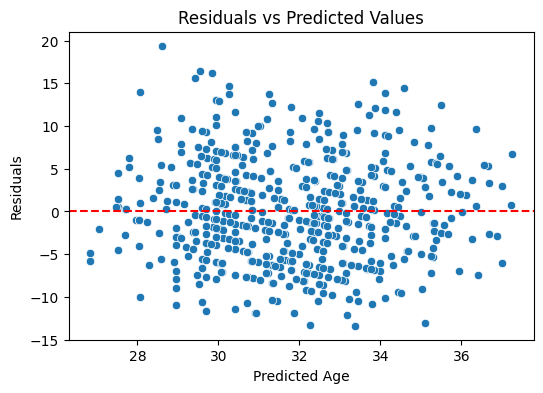

In [83]:
##linearity ##

import matplotlib.pyplot as plt
import seaborn as sns

# Predicted values
y_pred = sm_model.predict(sm.add_constant(X_train))

# Residuals
residuals = Y_train - y_pred

# Residual plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Age')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

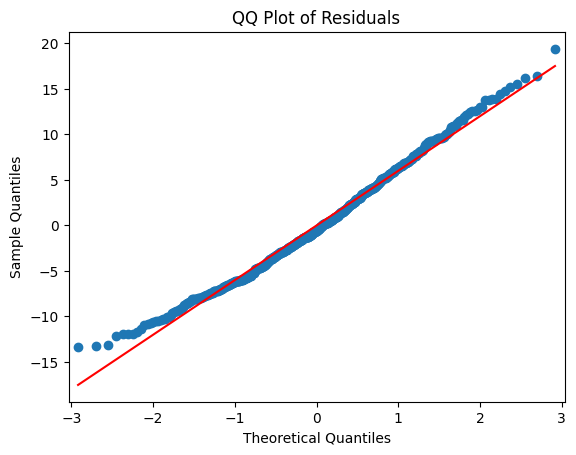

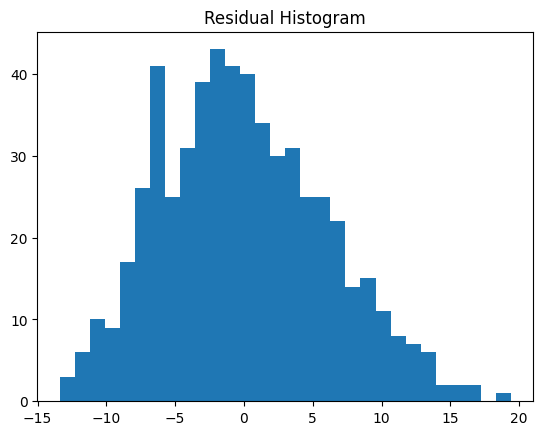

In [84]:
##normality ##

import scipy.stats as stats

# QQ plot
sm.qqplot(residuals, line='s')
plt.title('QQ Plot of Residuals')
plt.show()

# Histogram
plt.hist(residuals, bins=30)
plt.title('Residual Histogram')
plt.show()

In [85]:
#Homoscedasticity##

from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, sm.add_constant(X_train))
labels = ['Lagrange multiplier stat', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

{'Lagrange multiplier stat': np.float64(23.627735455984457), 'p-value': np.float64(0.12990780275240763), 'f-value': np.float64(1.4042882565131711), 'f p-value': np.float64(0.12824118257574066)}


In [86]:
##multiclinearity##

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train)
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

                          feature        VIF
0                           const  10.226079
1                          Gender   1.064781
2                   self_employed   1.227491
3                  family_history   1.048407
4                     remote_work   1.151863
5                    tech_company   1.066429
6            work_interfere_Often   1.061908
7                    benefits_Yes   1.525144
8                care_options_Yes   1.345934
9            wellness_program_Yes   1.202069
10            leave_Somewhat easy   1.154698
11           leave_Very difficult   1.216174
12                leave_Very easy   1.162133
13  mental_health_consequence_Yes   1.328760
14    phys_health_consequence_Yes   1.233514
15    mental_health_interview_Yes   1.212124
16      phys_health_interview_Yes   1.229092
17          Country_clean_Ireland   1.045756


In [87]:
df_clean.to_csv("/kaggle/working/df_clean_backup.csv", index=False)
df_clean.to_pickle("/kaggle/working/df_clean_backup.pkl")

print("Backup saved")

Backup saved


In [88]:
X_train.to_csv("/kaggle/working/X_train.csv", index=False)
X_val.to_csv("/kaggle/working/X_val.csv", index=False)
X_test.to_csv("/kaggle/working/X_test.csv", index=False)

Y_train.to_csv("/kaggle/working/Y_train.csv", index=False)
Y_val.to_csv("/kaggle/working/Y_val.csv", index=False)
Y_test.to_csv("/kaggle/working/Y_test.csv", index=False)

print("Train/val/test files saved")

Train/val/test files saved


In [89]:
##Predictive power is very weak. Even the significant variables shift Age by only 1–3 years. The linear model struggles because: Most features are binary/categorical → linear regression assumes numeric continuous inputs. Age variance is low (18–49) → harder to predict.##

In [90]:
##The linearity test showed that the relationship between the predictors and residuals was not linear, indicating that a linear regression model is not appropriate for this dataset. Although the same predictors performed well earlier in classification models, that was with a different outcome variable (treatment) rather than Age. In this case, the predictors appear to have only weak relationships with Age, which explains the low R² and poor model fit. Therefore, linear regression is not suitable for modelling age in this dataset.##